# r/t amplitude-coefficient and spatial-field cross-validation - 1D anisotropic grating, oblique incidence

Compares complex amplitudes per diffracted order against RETICOLO, rather than the
summed diffraction efficiencies.

| | efficiency-only comparison | this case |
|---|---|---|
| compared quantity | `sum(efficiency)` over all orders | complex amplitude **per order** |
| symbol | `R`, `T` (power) | `r_m`, `t_m` (amplitude) |
| phase | not compared | compared |
| catches per-order redistribution | no | yes |
| catches sign / branch errors | no | yes |

Summing over orders lets per-order errors cancel and throws phase away.

**This does not establish convergence.** Two implementations can agree closely at the same
truncation and both still be short of the exact answer. A separate `fto` sweep is what shows
convergence; that is not what this case does.

## This case

* geometry: four cells across the period, the middle two being the grating bar
* index: a diagonal tensor (nx, ny, nz) = (1.5, 2.0, 2.5)
* incidence: oblique classical mount (theta = 30 deg, phi = 0)

## Notation

Lowercase `r`, `t` are complex amplitude coefficients - what this compares. Uppercase `R`, `T`
are power efficiencies - what `res.de_ri` and `res.de_ti` hold. File names follow the same rule.

## Normalization

RETICOLO normalizes amplitude to energy flux through the xy plane, so
`efficiency = |amplitude|^2`. meent keeps the obliquity factor outside, so
`de_ri = |R_s|^2 * f` with `f = Re(kz/(n_top*cos(theta)))`. The bridge is
`r_m = R_s * sqrt(f)`, applied in `_compare.py`, and section 2 verifies it against meent's
own efficiencies **before** anything is compared to RETICOLO.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

SEARCH_START = Path.cwd().resolve()

def _find_simulation_root(start):
    for d in [start, *start.parents]:
        direct = d / '_compare.py'
        nested = d / 'validation' / 'simulation' / '_compare.py'
        if direct.is_file():
            return d
        if nested.is_file():
            return nested.parent
    raise FileNotFoundError(f'validation/simulation not found from {start}')

SIMULATION_ROOT = _find_simulation_root(SEARCH_START)
MEENT_ROOT = SIMULATION_ROOT.parents[1]
WORKDIR = SIMULATION_ROOT / 'lossless' / '1D_anisotropic_grating_oblique_incidence'
sys.path.insert(0, str(MEENT_ROOT))
sys.path.insert(0, str(SIMULATION_ROOT))

import meent
import _compare as C

print('meent   :', meent.__file__)
print('workdir :', WORKDIR)
assert str(MEENT_ROOT) in meent.__file__, (
    'meent came from elsewhere - restart the kernel so the sys.path insert wins')
import _field_compare as F


meent   : E:\Taesang Yun\meent\meent\__init__.py
workdir : E:\Taesang Yun\meent\validation\simulation\lossless\1D_anisotropic_grating_oblique_incidence


In [2]:
case = C.Case(
    name='1D_anisotropic_grating_oblique_incidence',
    theta_deg=30.0, phi_deg=0.0,
    n_grating=(1.5, 2.0, 2.5),
    n_slab=(1.5, 2.0, 2.5),
    n_bg=(1.0, 1.0, 1.0),
    period=(1000e-9,),
    thickness=(500e-9, 500e-9),
    grating_width=500e-9,
    grating_center=500e-9,
    fto=(100,),
    order_window=6,
    # General-wavelength sweep: offset from exact modal cutoffs.
    wavelength_m=(500.5e-9, 700.5e-9, 1e-9),
    quick=False,
)
print(f'case   : {case.name}')
print(f'dim    : {case.dim}D   anisotropic: {case.aniso}')
print(f'theta  : {np.degrees(np.real(case.theta)):.1f} deg   phi: {case.phi_deg:.1f} deg')
print(f'k_par  : {case.k_par:.6f}   (RETICOLO angle_delta = {-case.phi_deg:.0f})')
print(f'fto    : {case.fto}   order window: +-{case.order_window}')
print(f'lambda : {len(case.wavelengths)} points '
      f'({case.wavelengths[0]:.6g}-{case.wavelengths[-1]:.6g} m)')
print(f'solves : {len(case.methods) * len(case.pols) * len(case.wavelengths)}')

case   : 1D_anisotropic_grating_oblique_incidence
dim    : 1D   anisotropic: True
theta  : 30.0 deg   phi: 0.0 deg
k_par  : 0.500000   (RETICOLO angle_delta = -0)
fto    : (100,)   order window: +-6
lambda : 201 points (5.005e-07-7.005e-07 m)
solves : 1206


## 1. meent sweep

One file per (polarization, direction, method), one row per diffracted order per wavelength -
the same layout the `.m` file writes.

In [3]:
failures_sweep, selfcheck = C.run_sweep(case, WORKDIR)

  discrete    TE r   2613/ 2613 finite  ->  Meent_1D_anisotropic_grating_oblique_incidence_TE_r_discrete.txt
  discrete    TE t   2613/ 2613 finite  ->  Meent_1D_anisotropic_grating_oblique_incidence_TE_t_discrete.txt
  discrete    TM r   2613/ 2613 finite  ->  Meent_1D_anisotropic_grating_oblique_incidence_TM_r_discrete.txt
  discrete    TM t   2613/ 2613 finite  ->  Meent_1D_anisotropic_grating_oblique_incidence_TM_t_discrete.txt
  continuous  TE r   2613/ 2613 finite  ->  Meent_1D_anisotropic_grating_oblique_incidence_TE_r_continuous.txt
  continuous  TE t   2613/ 2613 finite  ->  Meent_1D_anisotropic_grating_oblique_incidence_TE_t_continuous.txt
  continuous  TM r   2613/ 2613 finite  ->  Meent_1D_anisotropic_grating_oblique_incidence_TM_r_continuous.txt
  continuous  TM t   2613/ 2613 finite  ->  Meent_1D_anisotropic_grating_oblique_incidence_TM_t_continuous.txt
  vector      TE r   2613/ 2613 finite  ->  Meent_1D_anisotropic_grating_oblique_incidence_TE_r_vector.txt
  vector     

## 2. Self-check

meent against meent - no RETICOLO involved, and not a physics test. Everything downstream
depends on the `sqrt(f)` bridge being right, so this runs first. The sum runs over **all**
orders, not just the window written to file, so it also confirms nothing outside the window
carries energy.

In [4]:
dev = C.check_selfcheck(case, selfcheck)

checked  : 2412 (method, pol, wavelength, direction) combinations
max dev  : 4.441e-16
median   : 5.551e-17

OK - reproduces meent efficiencies to better than 1e-12


## 3. Magnitude, per order

`|a|` is phase-free, so once the normalization matches this part is unambiguous. Any per-order
redistribution shows up here even when the summed quantities agree.

In [10]:
per_order, unmatched, mag_worst = C.compare_magnitude(case, WORKDIR)

pol  dir  method         max d|a|      median      n
----------------------------------------------------
TE   r    discrete      1.123e-05   9.708e-07    603
TE   r    continuous    2.533e-12   2.033e-13    603
TE   r    vector        4.507e-12   2.268e-13    603
TE   t    discrete      1.547e-05   1.190e-06    603
TE   t    continuous    2.158e-12   2.232e-13    603
TE   t    vector        3.136e-12   2.267e-13    603
TM   r    discrete      2.416e-05   1.915e-06    603
TM   r    continuous    4.101e-11   2.200e-13    603
TM   r    vector        4.182e-11   2.323e-13    603
TM   t    discrete      1.737e-05   1.694e-06    603
TM   t    continuous    2.725e-11   2.188e-13    603
TM   t    vector        2.655e-11   2.406e-13    603


The table above is a maximum over every order at once, which is how one bad order hides behind
a good one. Split by order:

In [11]:
C.report_per_order(case, per_order, unmatched)

--- TE incidence, r ---
   order           -2          -1          +0
discrete     5.74e-06    9.99e-06    1.12e-05
continuous     2.53e-12    2.12e-12    2.45e-12
  vector     2.95e-12    2.48e-12    4.51e-12

--- TE incidence, t ---
   order           -2          -1          +0
discrete     8.75e-06    6.58e-06    1.55e-05
continuous     2.16e-12    1.87e-12    1.36e-12
  vector     2.54e-12    1.86e-12    3.14e-12

--- TM incidence, r ---
   order           -2          -1          +0
discrete     1.71e-05    9.48e-06    2.42e-05
continuous     4.10e-11    2.90e-11    2.05e-11
  vector     4.18e-11    2.77e-11    2.12e-11

--- TM incidence, t ---
   order           -2          -1          +0
discrete     1.13e-05    1.34e-05    1.74e-05
continuous     1.25e-11    2.72e-11    2.61e-11
  vector     1.22e-11    2.52e-11    2.65e-11

every RETICOLO (wavelength, order) had a meent counterpart


## 4. Direct complex-amplitude comparison

Meent coefficients are exported in RETICOLO's normalization and modal convention. The
comparison subtracts the raw complex values directly, without fitting phase, amplitude,
signs, or conjugation. Every propagating order, both polarization components, and both
directions (r and t) remain in one comparison vector.

No per-component or per-direction adjustment is allowed, so a relative TE/TM or r/t phase
error remains visible.

The conjugate hypothesis is measured only as a diagnostic and is never used for PASS.

In [12]:
print(f"{'pol':4s} {'method':11s} {'max err':>11s} {'median':>11s} {'n_wl':>6s}")
print('-' * 46)
phase_worst, conj_votes, phase_n = C.compare_phase(case, WORKDIR)

pol  method          max err      median   n_wl
----------------------------------------------
TE   discrete      1.395e-03   8.593e-04    201
TE   continuous    3.344e-12   6.695e-13    201
TE   vector        4.515e-12   6.763e-13    201
TM   discrete      1.265e-03   9.389e-04    201
TM   continuous    4.140e-11   5.566e-13    201
TM   vector        4.224e-11   7.477e-13    201

Time convention: matched as-is (100.0% of wavelengths).


In [13]:
N_WORST = 12
omark = (lambda m: f'{m[0]:+d}' if case.dim == 1 else f'{m[0]:+d},{m[1]:+d}')

print('worst magnitude deviations')
print(f"{'d|a|':>11s} {'pol':4s} {'dir':4s} {'method':11s} {'lambda':>9s} {'order':>8s}")
print('-' * 56)
for v, pol, d, method, lam, m in sorted(mag_worst, reverse=True)[:N_WORST]:
    print(f'{v:11.3e} {C.POL_NAME[pol]:4s} {d:4s} {method:11s} {lam:11.6g} m {omark(m):>8s}')

print()
print('worst direct complex deviations')
print(f"{'err':>11s} {'pol':4s} {'method':11s} {'lambda':>9s} {'alpha (rad)':>12s}")
print('-' * 52)
for v, pol, method, lam, alpha in sorted(phase_worst, reverse=True)[:N_WORST]:
    print(f'{v:11.3e} {C.POL_NAME[pol]:4s} {method:11s} {lam:11.6g} m {alpha:12.5f}')

worst magnitude deviations
       d|a| pol  dir  method         lambda    order
--------------------------------------------------------
  2.416e-05 TM   r    discrete      5.275e-07 m       +0
  1.768e-05 TM   r    discrete      5.265e-07 m       +0
  1.737e-05 TM   t    discrete      5.255e-07 m       +0
  1.725e-05 TM   t    discrete      5.265e-07 m       +0
  1.708e-05 TM   r    discrete      5.705e-07 m       -2
  1.595e-05 TM   t    discrete      6.235e-07 m       +0
  1.587e-05 TM   t    discrete      5.565e-07 m       +0
  1.559e-05 TM   r    discrete      5.145e-07 m       -2
  1.547e-05 TE   t    discrete      5.185e-07 m       +0
  1.521e-05 TM   t    discrete      6.225e-07 m       +0
  1.484e-05 TE   t    discrete      5.175e-07 m       +0
  1.476e-05 TM   r    discrete      6.225e-07 m       -2

worst phase-aligned complex deviations
        err pol  method         lambda  alpha (rad)
----------------------------------------------------
  1.395e-03 TE   discrete      5.1

## 5. Verdict

Everything above prints. This cell **raises**, so a run that ends without an exception is the
pass signal and a notebook full of quiet mismatches cannot look green.

In [14]:
C.verdict(case, WORKDIR, failures_sweep, dev, per_order, unmatched, phase_worst, phase_n)

0 failure(s)

PASS - meent agrees with RETICOLO on every checked coefficient.


## 6. Plots

Real and imaginary parts of the complex coefficient per order, **not** `|a|`. A magnitude
plot hides what this case exists to catch: two solvers can agree on every magnitude and
still differ by a sign, a conjugation, or a per-order reference-plane phase. The verdict is
a direct complex difference, so the plot shows the same numbers it is computed from.


In [ ]:
fig = C.plot_coefficients(case, WORKDIR, pol=0)
plt.show()


## 7. Single-wavelength field settings

Set FIELD_WAVELENGTH_M below and run the settings cell. It writes field_wavelength_m.txt; then set RUN_FIELD_PROFILE = true in RETICOLO_1D_anisotropic_grating_oblique_incidence.m and run it in MATLAB. Set RUN_COMPLEX_COEFFICIENTS = false there when only the field reference is needed, then return to this notebook. Grid sizes and buffer thicknesses are read from the saved RETICOLO file so both solvers use the same values.


In [16]:
FIELD_WAVELENGTH_M = 600e-9
FIELD_METHOD = 'continuous'  # discrete, continuous, or vector
SAVE_FIELD_PLOTS = True

print(f'field wavelength: {FIELD_WAVELENGTH_M:.6g} m')
print(f'meent method   : {FIELD_METHOD}')
F.write_field_request(WORKDIR, FIELD_WAVELENGTH_M)


field wavelength: 6e-07 m
meent method   : continuous
field request written: field_wavelength_m.txt = 6e-07 m


WindowsPath('E:/Taesang Yun/meent/validation/simulation/lossless/1D_anisotropic_grating_oblique_incidence/field_wavelength_m.txt')

## 8. Field comparison and saved profiles

This solves only the selected wavelength for TE and TM incidence. RETICOLO's stored field values are left untouched; Meent `calculate_field()` already returns RETICOLO's time and Cartesian-component convention, so the complex fields are subtracted directly with no phase or amplitude fit. Relative L2 errors are printed separately for the superstrate, grating, slab, and substrate; discontinuous edge-normal electric components retain their separate `tol_field_edge`.

The cell then **raises** on any entry over tolerance, after the plots are drawn, so a field regression cannot leave a green-looking notebook.


RETICOLO reference: RETICOLO_1D_anisotropic_grating_oblique_incidence_field_6e-07m.mat
Meent method: continuous; grid: z=124, y=1, x=81
global phase removed: TE=5.58969e-14 rad, TM=-3.14159 rad
pol  region               Ex         Ey         Ez         Hx         Hy         Hz
--------------------------------------------------------------------------------------
TE   superstrate   0.000e+00  9.190e-13  0.000e+00  8.154e-13  0.000e+00  1.314e-12
TE   grating       0.000e+00  1.765e-12  0.000e+00  1.654e-12  0.000e+00  1.970e-12
TE   slab          0.000e+00  1.935e-12  0.000e+00  1.944e-12  0.000e+00  1.864e-12
TE   substrate     0.000e+00  1.932e-12  0.000e+00  1.919e-12  0.000e+00  1.948e-12
TM   superstrate   6.999e-13  0.000e+00  9.634e-13  0.000e+00  5.580e-13  0.000e+00
TM   grating       5.634e-02  0.000e+00  1.194e-12  0.000e+00  7.668e-13  0.000e+00
TM   slab          6.604e-13  0.000e+00  8.573e-13  0.000e+00  7.273e-13  0.000e+00
TM   substrate     7.352e-13  0.000e+00  8.158e

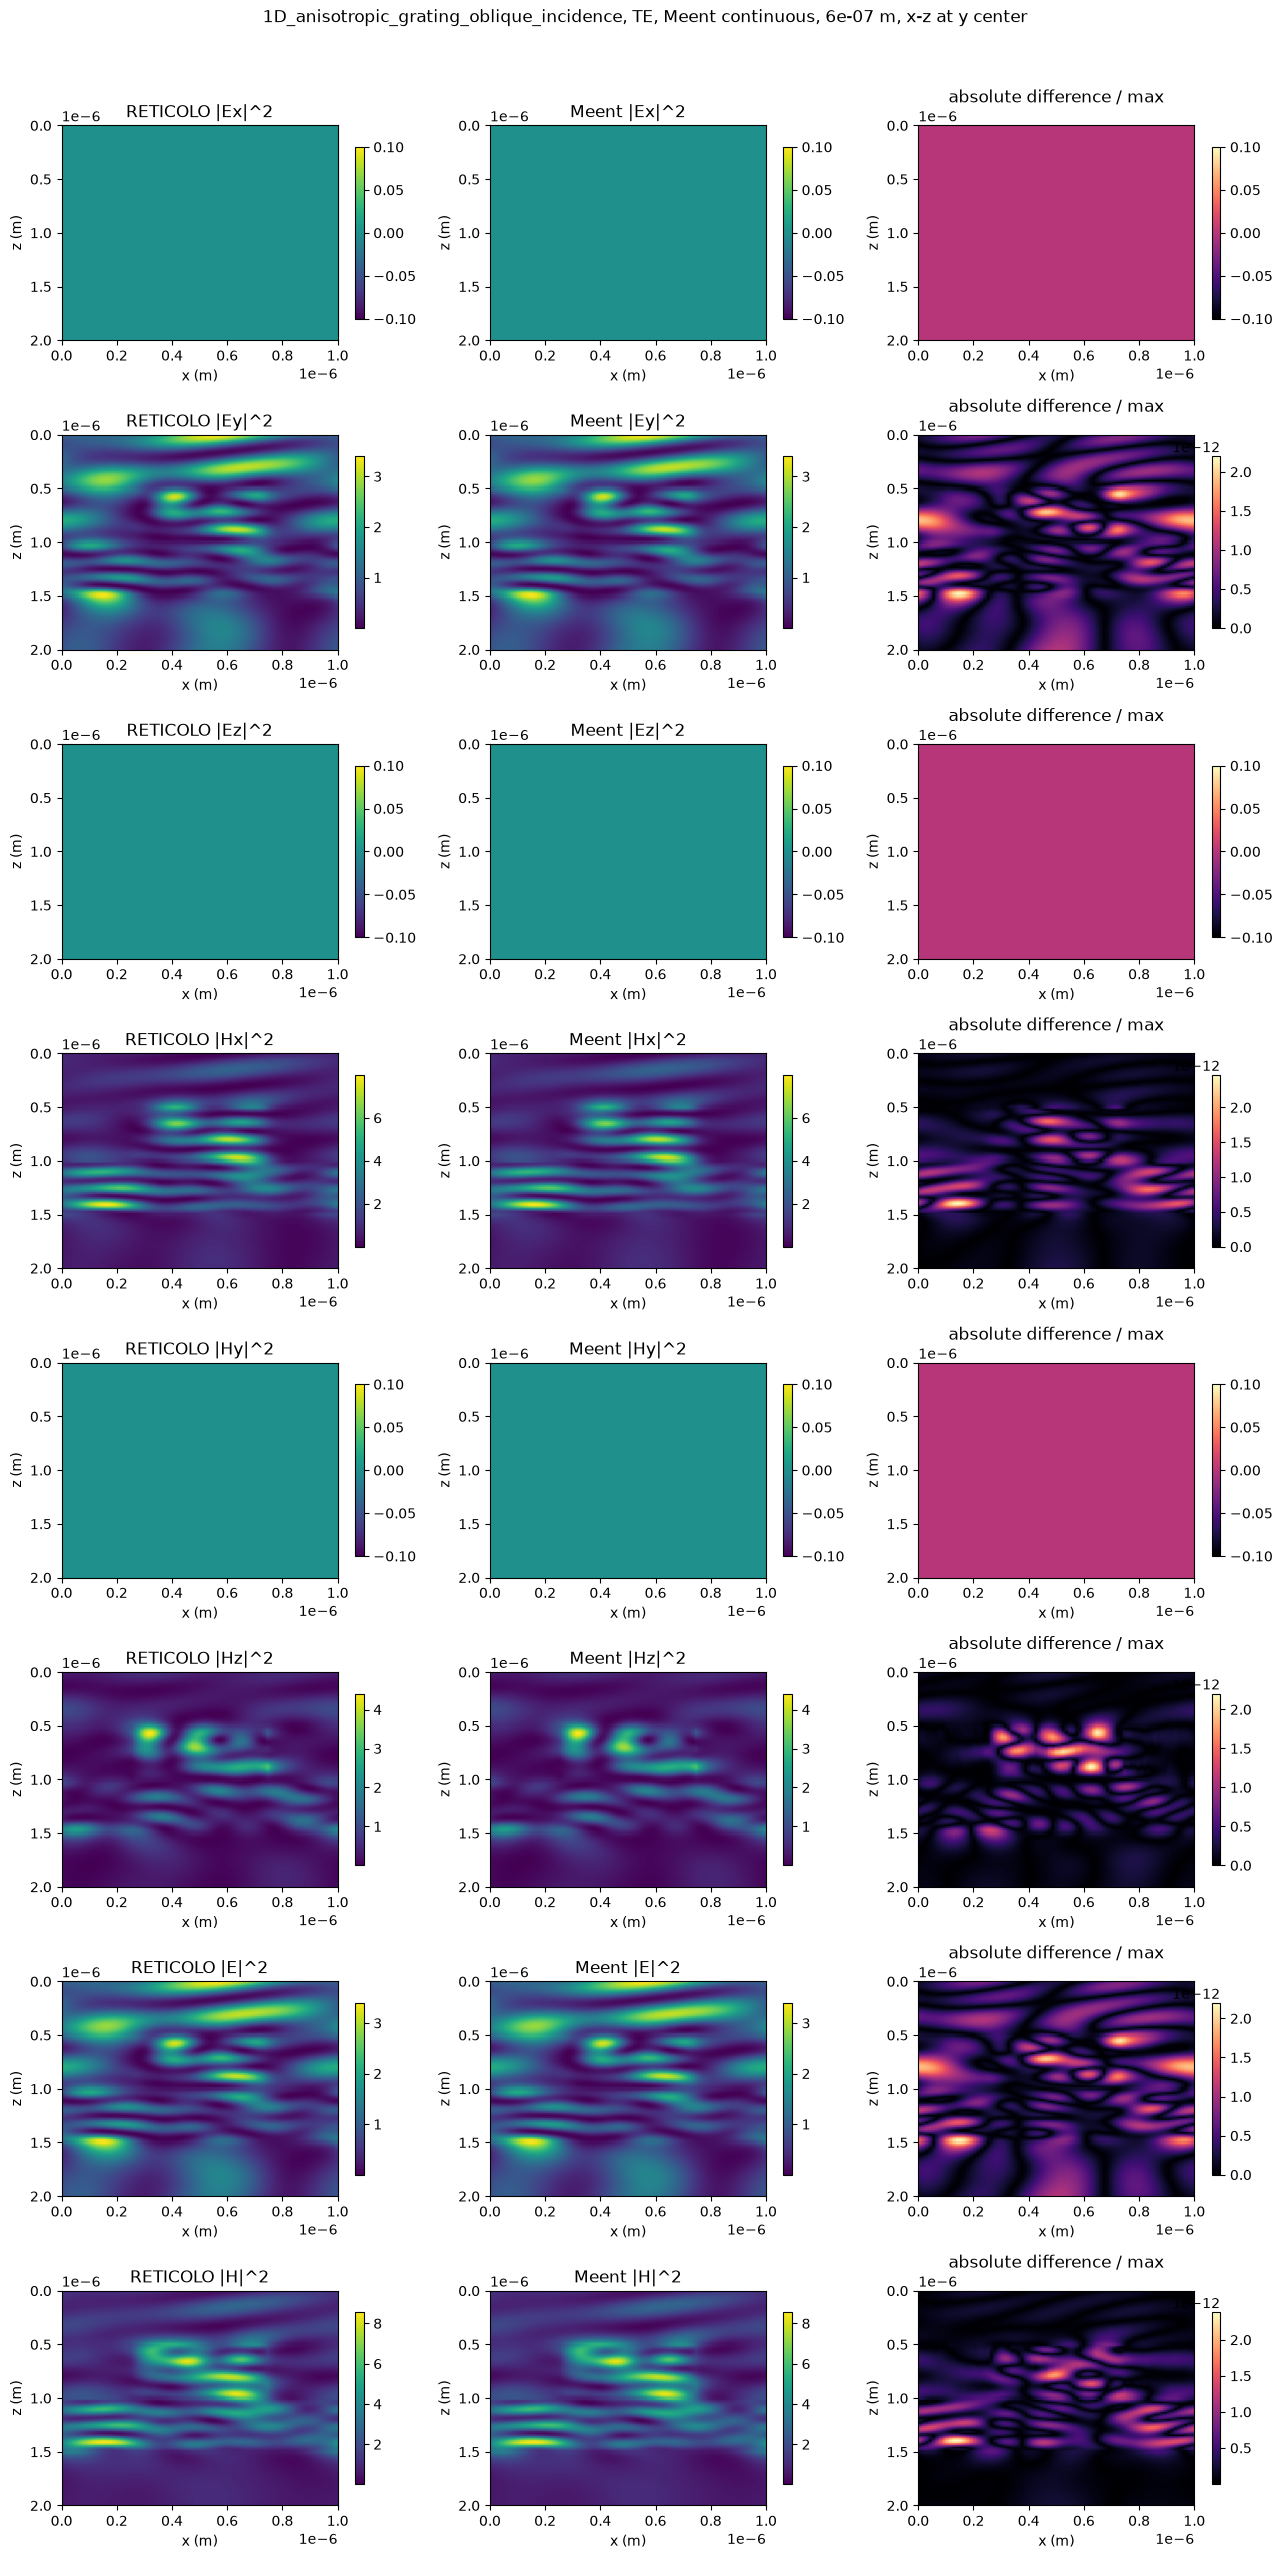

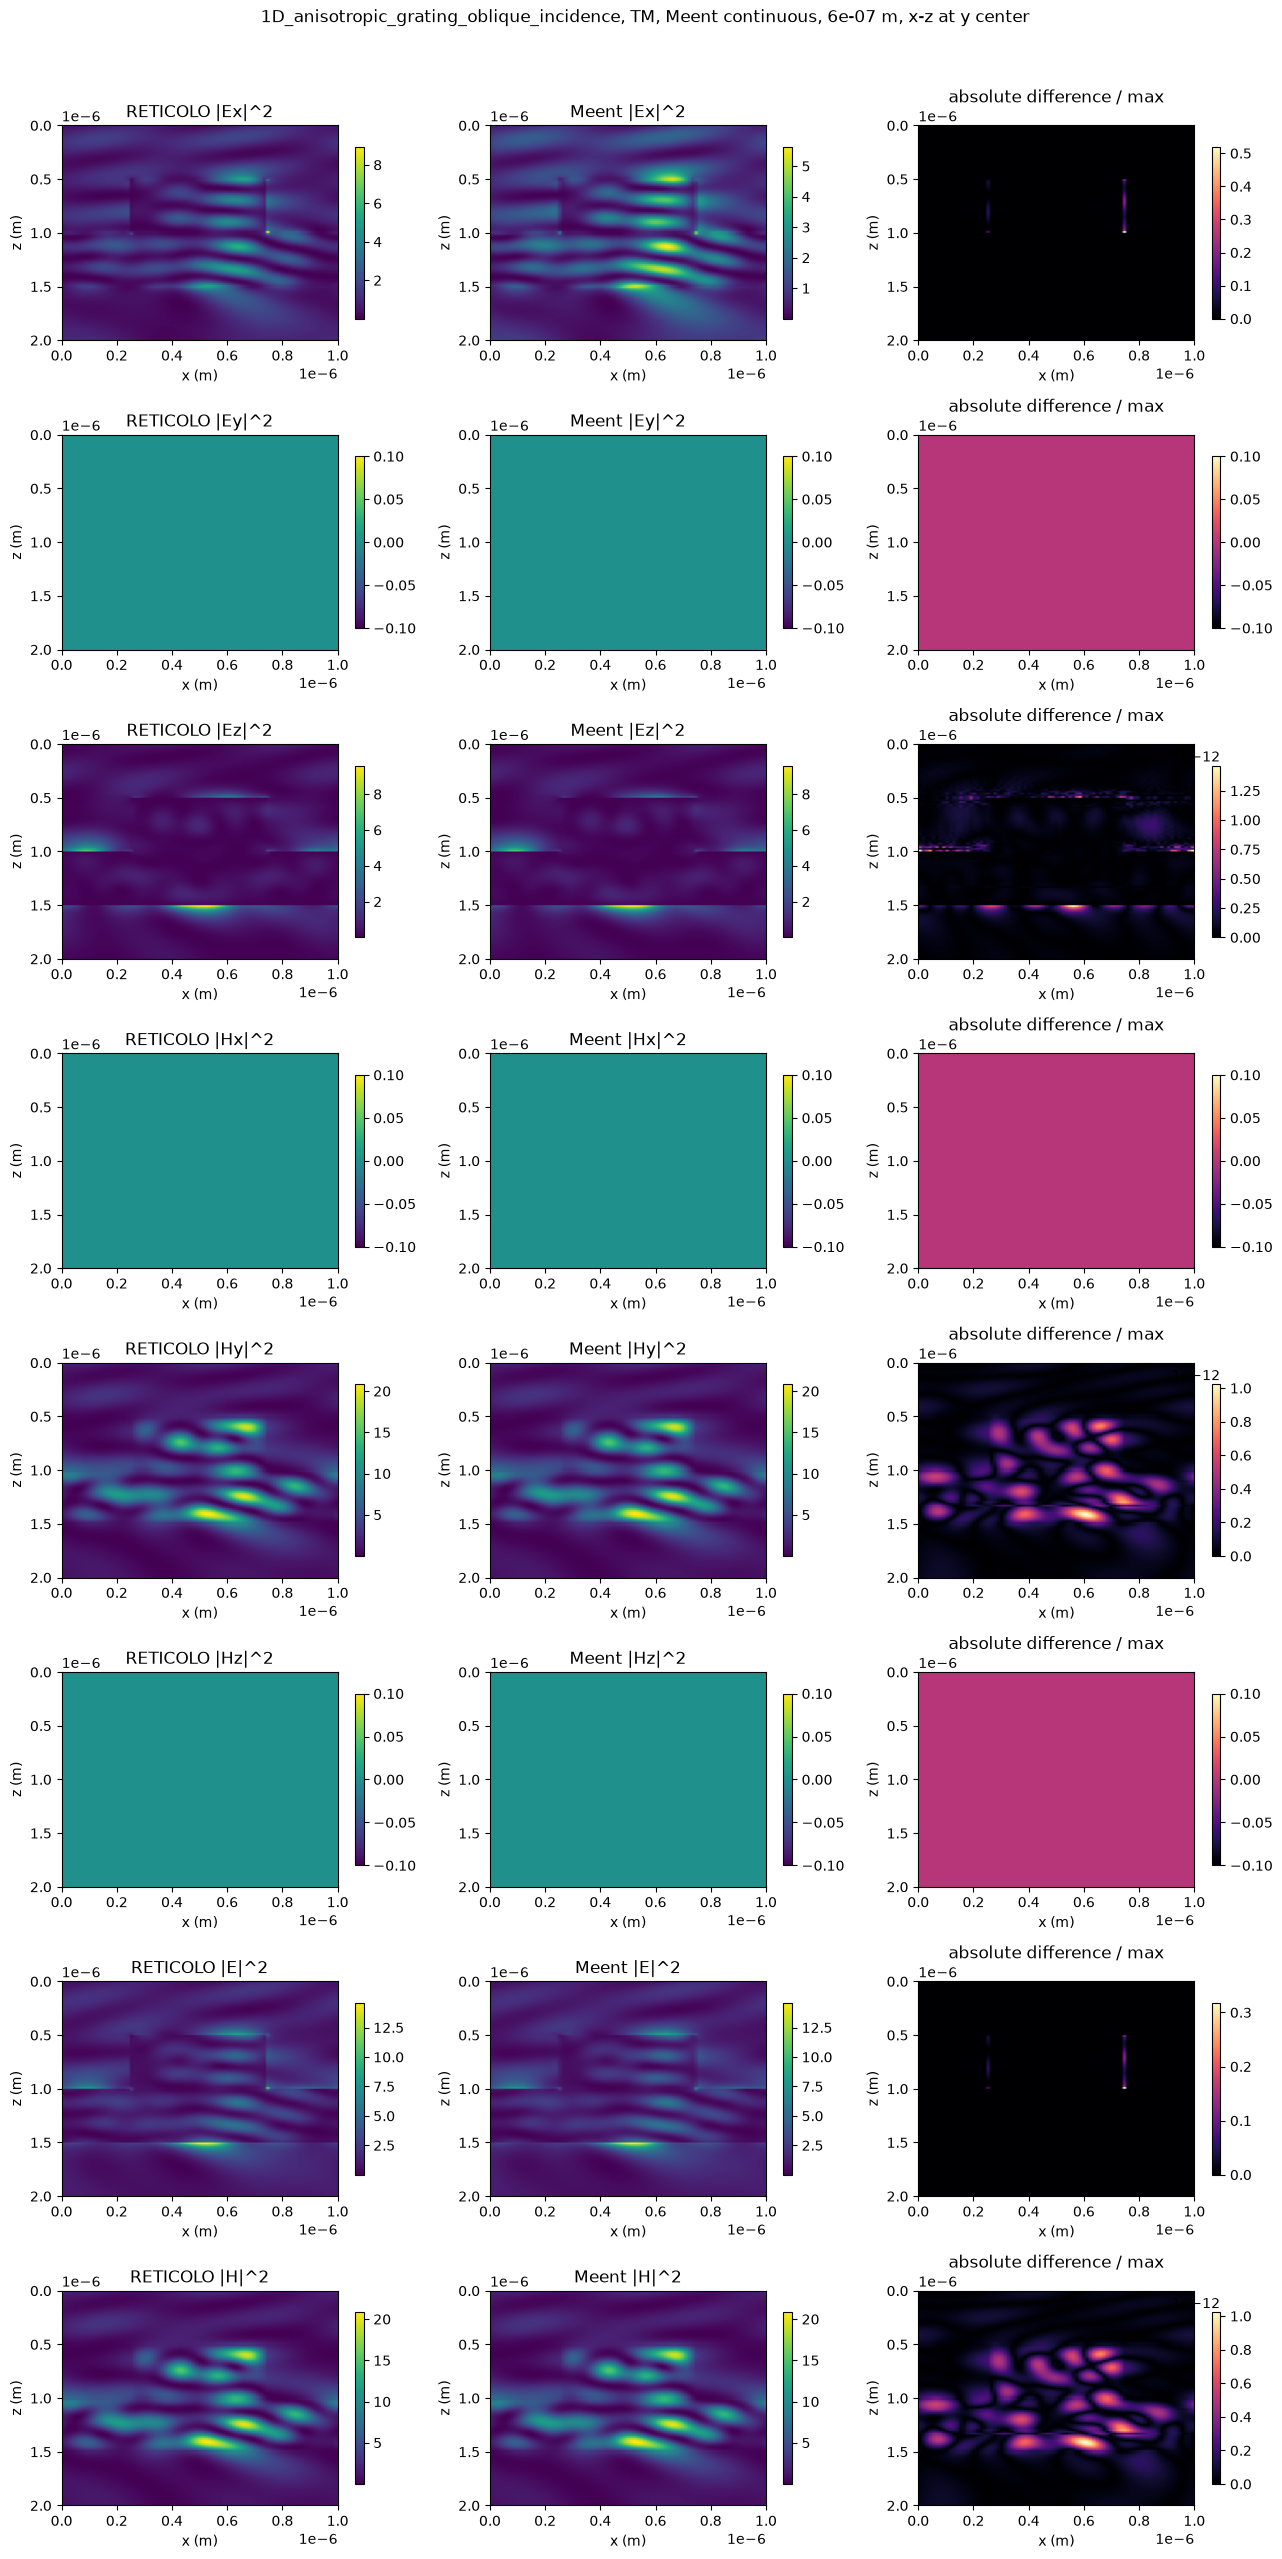

0 field failure(s)

PASS - Meent agrees with RETICOLO everywhere within 1e-08 (0.2 for the electric component normal to the grating edge).


In [17]:
field_result = F.compare_field_profile(
    case, WORKDIR,
    wavelength_m=FIELD_WAVELENGTH_M,
    method=FIELD_METHOD,
    save_plots=SAVE_FIELD_PLOTS,
)
